In [ ]:
# 04 - Model Evaluation

This notebook performs participant-level evaluation of machine-learning
models for Parkinson's disease classification.

Primary models:
- Logistic Regression
- Support Vector Machine
- Random Forest

Evaluation strategy:
- 5-fold stratified participant-grouped cross-validation
- No participant appears in both training and validation data
- Decision thresholds are selected using training data only
- Recording-level model scores are aggregated to participant level
- Primary metrics include balanced accuracy, sensitivity, specificity,
  precision, F1 score, and ROC-AUC

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

In [2]:
PROJECT_DIR = Path.cwd().parent

FEATURE_PATH = (
    PROJECT_DIR
    / "outputs"
    / "tables"
    / "pads_recording_features.csv"
)

df = pd.read_csv(
    FEATURE_PATH,
    dtype={"subject_id": str}
)

df["subject_id"] = df["subject_id"].str.zfill(3)

print("Dataset shape:", df.shape)
print("Participants:", df["subject_id"].nunique())
print("Parkinson's participants:",
      df.loc[df["target"] == 1, "subject_id"].nunique())
print("Healthy participants:",
      df.loc[df["target"] == 0, "subject_id"].nunique())

Dataset shape: (7810, 101)
Participants: 355
Parkinson's participants: 276
Healthy participants: 79


In [5]:
metadata_columns = [
    "subject_id",
    "task",
    "wrist",
    "condition",
    "target"
]

feature_columns = [
    col for col in df.columns
    if col not in metadata_columns
]

X = df[feature_columns]
y = df["target"]
groups = df["subject_id"]

print("Recordings:", len(X))
print("Features:", len(feature_columns))
print("Participants:", groups.nunique())

Recordings: 7810
Features: 96
Participants: 355


In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=False,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

In [9]:
def get_model_scores(model, X_data):

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]

    return model.decision_function(X_data)

In [11]:
def aggregate_to_participant(data_subset, scores):

    temp = data_subset[
        ["subject_id", "condition", "target"]
    ].copy()

    temp["score"] = scores

    participant_df = (
        temp
        .groupby(
            ["subject_id", "condition", "target"],
            as_index=False
        )
        .agg(
            mean_score=("score", "mean"),
            n_recordings=("score", "size")
        )
    )

    return participant_df

In [13]:
def select_threshold(y_true, scores):

    fpr, tpr, thresholds = roc_curve(
        y_true,
        scores
    )

    youden_j = tpr - fpr

    finite_mask = np.isfinite(thresholds)

    valid_thresholds = thresholds[finite_mask]
    valid_j = youden_j[finite_mask]

    best_index = np.argmax(valid_j)

    return valid_thresholds[best_index]

In [15]:
def get_training_threshold(
    base_model,
    train_df,
    feature_columns,
    n_inner_splits=3
):

    inner_cv = StratifiedGroupKFold(
        n_splits=n_inner_splits,
        shuffle=True,
        random_state=42
    )

    X_inner = train_df[feature_columns]
    y_inner = train_df["target"]
    groups_inner = train_df["subject_id"]

    participant_predictions = []

    for inner_train_idx, inner_val_idx in inner_cv.split(
        X_inner,
        y_inner,
        groups_inner
    ):

        model = clone(base_model)

        model.fit(
            X_inner.iloc[inner_train_idx],
            y_inner.iloc[inner_train_idx]
        )

        scores = get_model_scores(
            model,
            X_inner.iloc[inner_val_idx]
        )

        val_data = train_df.iloc[
            inner_val_idx
        ].reset_index(drop=True)

        participant_df = aggregate_to_participant(
            val_data,
            scores
        )

        participant_predictions.append(
            participant_df
        )

    oof_participants = pd.concat(
        participant_predictions,
        ignore_index=True
    )

    threshold = select_threshold(
        oof_participants["target"],
        oof_participants["mean_score"]
    )

    return threshold

In [17]:
outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results = []
all_participant_predictions = []

for model_name, base_model in models.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    for fold, (train_idx, val_idx) in enumerate(
        outer_cv.split(X, y, groups),
        start=1
    ):

        train_df = df.iloc[
            train_idx
        ].reset_index(drop=True)

        val_df = df.iloc[
            val_idx
        ].reset_index(drop=True)

        # -------------------------
        # Select threshold using
        # TRAINING participants only
        # -------------------------

        threshold = get_training_threshold(
            base_model,
            train_df,
            feature_columns,
            n_inner_splits=3
        )

        # -------------------------
        # Train final fold model
        # -------------------------

        model = clone(base_model)

        model.fit(
            train_df[feature_columns],
            train_df["target"]
        )

        # -------------------------
        # Evaluate unseen fold
        # -------------------------

        scores = get_model_scores(
            model,
            val_df[feature_columns]
        )

        participant_df = aggregate_to_participant(
            val_df,
            scores
        )

        participant_df["prediction"] = (
            participant_df["mean_score"] >= threshold
        ).astype(int)

        participant_df["Model"] = model_name
        participant_df["Fold"] = fold
        participant_df["Threshold"] = threshold

        y_true = participant_df["target"]
        y_pred = participant_df["prediction"]
        y_score = participant_df["mean_score"]

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp)

        results = {
            "Model": model_name,
            "Fold": fold,
            "Threshold": threshold,

            "N Participants": len(
                participant_df
            ),

            "Accuracy": accuracy_score(
                y_true, y_pred
            ),

            "Balanced Accuracy":
                balanced_accuracy_score(
                    y_true, y_pred
                ),

            "Precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

            "Sensitivity": recall_score(
                y_true,
                y_pred
            ),

            "Specificity": specificity,

            "F1": f1_score(
                y_true,
                y_pred
            ),

            "ROC-AUC": roc_auc_score(
                y_true,
                y_score
            )
        }

        fold_results.append(results)

        all_participant_predictions.append(
            participant_df
        )

        print(
            f"Fold {fold}: "
            f"N={len(participant_df)}, "
            f"threshold={threshold:.3f}, "
            f"balanced acc="
            f"{results['Balanced Accuracy']:.3f}, "
            f"AUC={results['ROC-AUC']:.3f}"
        )


Logistic Regression
Fold 1: N=71, threshold=0.488, balanced acc=0.801, AUC=0.911
Fold 2: N=71, threshold=0.492, balanced acc=0.771, AUC=0.845
Fold 3: N=71, threshold=0.502, balanced acc=0.724, AUC=0.847
Fold 4: N=71, threshold=0.514, balanced acc=0.802, AUC=0.890
Fold 5: N=71, threshold=0.485, balanced acc=0.773, AUC=0.887

SVM
Fold 1: N=71, threshold=0.046, balanced acc=0.852, AUC=0.925
Fold 2: N=71, threshold=0.044, balanced acc=0.802, AUC=0.881
Fold 3: N=71, threshold=0.018, balanced acc=0.822, AUC=0.917
Fold 4: N=71, threshold=0.002, balanced acc=0.837, AUC=0.936
Fold 5: N=71, threshold=0.089, balanced acc=0.802, AUC=0.889

Random Forest
Fold 1: N=71, threshold=0.756, balanced acc=0.843, AUC=0.933
Fold 2: N=71, threshold=0.773, balanced acc=0.812, AUC=0.878
Fold 3: N=71, threshold=0.766, balanced acc=0.789, AUC=0.909
Fold 4: N=71, threshold=0.786, balanced acc=0.817, AUC=0.912
Fold 5: N=71, threshold=0.738, balanced acc=0.837, AUC=0.920


In [19]:
cv_results = pd.DataFrame(fold_results)

display(
    cv_results.round(3)
)

,Model,Fold,Threshold,N Participants,Accuracy,Balanced Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC
0,Logistic Regression,1,0.488,71,0.873,0.801,0.948,0.902,0.700,0.924,0.911
1,Logistic Regression,2,0.492,71,0.775,0.771,0.913,0.778,0.765,0.840,0.845
2,Logistic Regression,3,0.502,71,0.718,0.724,0.881,0.712,0.737,0.787,0.847
3,Logistic Regression,4,0.514,71,0.803,0.802,0.911,0.804,0.800,0.854,0.890
4,Logistic Regression,5,0.485,71,0.775,0.773,0.938,0.776,0.769,0.849,0.887
5,SVM,1,0.046,71,0.817,0.852,0.980,0.803,0.900,0.883,0.925
6,SVM,2,0.044,71,0.761,0.802,0.951,0.722,0.882,0.821,0.881
7,SVM,3,0.018,71,0.789,0.822,0.951,0.750,0.895,0.839,0.917
8,SVM,4,0.002,71,0.831,0.837,0.933,0.824,0.850,0.875,0.936
9,SVM,5,0.089,71,0.676,0.802,1.000,0.603,1.000,0.753,0.889


In [21]:
print("Result rows:", len(cv_results))

Result rows: 15


In [23]:
metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC-AUC"
]

summary_rows = []

for model_name in cv_results["Model"].unique():

    model_data = cv_results[
        cv_results["Model"] == model_name
    ]

    row = {
        "Model": model_name
    }

    for metric in metrics:

        row[f"{metric} Mean"] = (
            model_data[metric].mean()
        )

        row[f"{metric} SD"] = (
            model_data[metric].std()
        )

    summary_rows.append(row)

cv_summary = pd.DataFrame(
    summary_rows
)

display(
    cv_summary.round(3)
)

,Model,Accuracy Mean,Accuracy SD,Balanced Accuracy Mean,Balanced Accuracy SD,Precision Mean,Precision SD,Sensitivity Mean,Sensitivity SD,Specificity Mean,Specificity SD,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD
0,Logistic Regression,0.789,0.056,0.774,0.032,0.918,0.026,0.794,0.069,0.754,0.038,0.851,0.049,0.876,0.029
1,SVM,0.775,0.061,0.823,0.022,0.963,0.027,0.740,0.087,0.905,0.056,0.834,0.052,0.910,0.024
2,Random Forest,0.800,0.021,0.820,0.022,0.947,0.027,0.786,0.031,0.854,0.042,0.858,0.022,0.910,0.020


In [25]:
OUTPUT_DIR = (
    PROJECT_DIR
    / "outputs"
    / "tables"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

cv_results.to_csv(
    OUTPUT_DIR
    / "five_fold_model_results.csv",
    index=False
)

cv_summary.to_csv(
    OUTPUT_DIR
    / "five_fold_model_summary.csv",
    index=False
)

participant_cv_predictions = pd.concat(
    all_participant_predictions,
    ignore_index=True
)

participant_cv_predictions.to_csv(
    OUTPUT_DIR
    / "five_fold_participant_predictions.csv",
    index=False
)

print("Files saved.")

Files saved.


In [ ]:
## Task-Specific Classification

To investigate which standardized motor assessments contained the most
discriminatory information, Random Forest classification performance was
evaluated separately for each of the 11 movement tasks.

Left- and right-wrist recordings for each task were aggregated at the
participant level. Participant-grouped cross-validation was maintained to
prevent subject-level data leakage.

In [31]:
task_results = []

tasks = sorted(df["task"].unique())

for task in tasks:

    print(f"Processing: {task}")

    task_df = df[
        df["task"] == task
    ].reset_index(drop=True)

    X_task = task_df[feature_columns]
    y_task = task_df["target"]
    groups_task = task_df["subject_id"]

    task_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for fold, (train_idx, val_idx) in enumerate(
        task_cv.split(
            X_task,
            y_task,
            groups_task
        ),
        start=1
    ):

        train_task_df = task_df.iloc[
            train_idx
        ].reset_index(drop=True)

        val_task_df = task_df.iloc[
            val_idx
        ].reset_index(drop=True)

        base_rf = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        # Select threshold using training participants only
        threshold = get_training_threshold(
            base_rf,
            train_task_df,
            feature_columns,
            n_inner_splits=3
        )

        model = clone(base_rf)

        model.fit(
            train_task_df[feature_columns],
            train_task_df["target"]
        )

        scores = model.predict_proba(
            val_task_df[feature_columns]
        )[:, 1]

        participant_df = aggregate_to_participant(
            val_task_df,
            scores
        )

        participant_df["prediction"] = (
            participant_df["mean_score"] >= threshold
        ).astype(int)

        y_true = participant_df["target"]
        y_pred = participant_df["prediction"]
        y_score = participant_df["mean_score"]

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        tn, fp, fn, tp = cm.ravel()

        task_results.append({
            "Task": task,
            "Fold": fold,
            "Accuracy": accuracy_score(
                y_true, y_pred
            ),
            "Balanced Accuracy":
                balanced_accuracy_score(
                    y_true, y_pred
                ),
            "Sensitivity": recall_score(
                y_true, y_pred
            ),
            "Specificity":
                tn / (tn + fp),
            "F1": f1_score(
                y_true, y_pred
            ),
            "ROC-AUC": roc_auc_score(
                y_true, y_score
            )
        })

Processing: CrossArms
Processing: DrinkGlas
Processing: Entrainment
Processing: HoldWeight
Processing: LiftHold
Processing: PointFinger
Processing: Relaxed
Processing: RelaxedTask
Processing: StretchHold
Processing: TouchIndex
Processing: TouchNose


In [28]:
task_results_df = pd.DataFrame(task_results)

task_summary = (
    task_results_df
    .groupby("Task")
    .agg(
        Balanced_Accuracy_Mean=(
            "Balanced Accuracy", "mean"
        ),
        Balanced_Accuracy_SD=(
            "Balanced Accuracy", "std"
        ),
        Sensitivity_Mean=(
            "Sensitivity", "mean"
        ),
        Specificity_Mean=(
            "Specificity", "mean"
        ),
        F1_Mean=(
            "F1", "mean"
        ),
        ROC_AUC_Mean=(
            "ROC-AUC", "mean"
        ),
        ROC_AUC_SD=(
            "ROC-AUC", "std"
        )
    )
    .sort_values(
        "Balanced_Accuracy_Mean",
        ascending=False
    )
)

display(task_summary.round(3))

,Balanced_Accuracy_Mean,Balanced_Accuracy_SD,Sensitivity_Mean,Specificity_Mean,F1_Mean,ROC_AUC_Mean,ROC_AUC_SD
Task,,,,,,,
StretchHold,0.741,0.056,0.639,0.842,0.754,0.806,0.072
HoldWeight,0.732,0.053,0.595,0.870,0.721,0.815,0.039
TouchNose,0.730,0.028,0.762,0.697,0.822,0.811,0.018
CrossArms,0.726,0.053,0.733,0.719,0.799,0.815,0.076
RelaxedTask,0.714,0.043,0.579,0.848,0.707,0.816,0.040
DrinkGlas,0.709,0.042,0.761,0.656,0.812,0.830,0.034
PointFinger,0.702,0.043,0.812,0.592,0.840,0.733,0.098
LiftHold,0.689,0.058,0.590,0.789,0.710,0.769,0.052
Relaxed,0.646,0.064,0.566,0.726,0.676,0.704,0.071


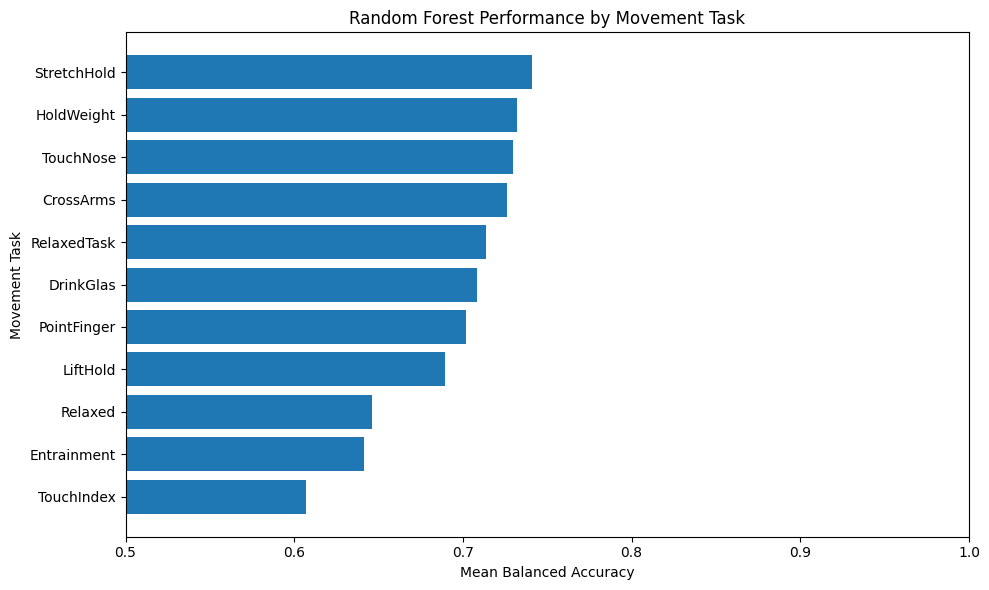

In [35]:
plt.figure(figsize=(10, 6))

plot_data = (
    task_summary
    .sort_values("Balanced_Accuracy_Mean")
)

plt.barh(
    plot_data.index,
    plot_data["Balanced_Accuracy_Mean"]
)

plt.xlabel("Mean Balanced Accuracy")
plt.ylabel("Movement Task")
plt.title(
    "Random Forest Performance by Movement Task"
)
plt.xlim(0.5, 1.0)
plt.tight_layout()

plt.show()

In [36]:
task_results_df.to_csv(
    OUTPUT_DIR / "task_specific_fold_results.csv",
    index=False
)

task_summary.to_csv(
    OUTPUT_DIR / "task_specific_summary.csv"
)

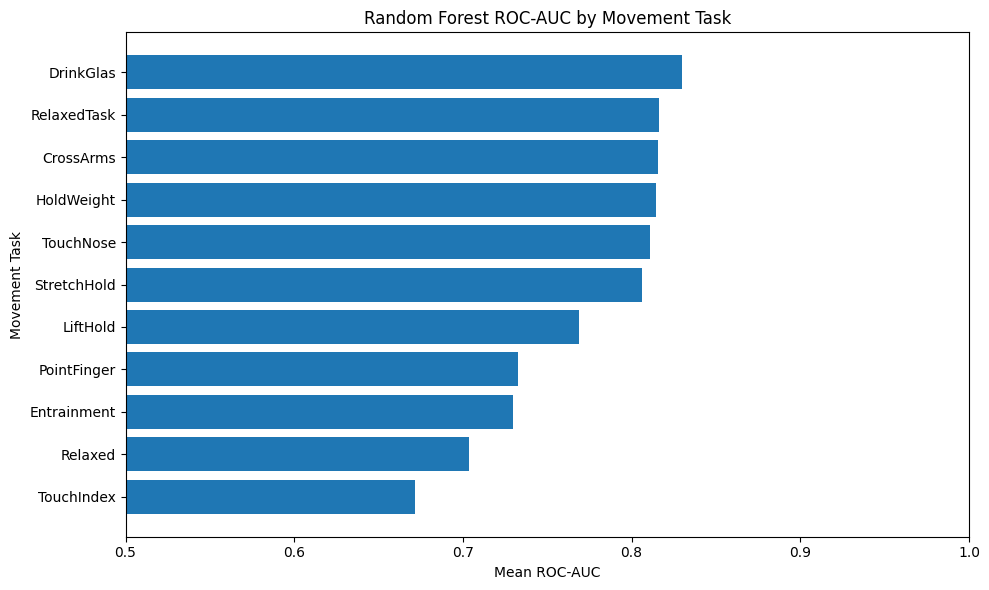

In [37]:
plt.figure(figsize=(10, 6))

plot_data = (
    task_summary
    .sort_values("ROC_AUC_Mean")
)

plt.barh(
    plot_data.index,
    plot_data["ROC_AUC_Mean"]
)

plt.xlabel("Mean ROC-AUC")
plt.ylabel("Movement Task")
plt.title(
    "Random Forest ROC-AUC by Movement Task"
)

plt.xlim(0.5, 1.0)
plt.tight_layout()

plt.show()

In [42]:
rf_feature_importances = []

feature_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(
    feature_cv.split(X, y, groups),
    start=1
):

    model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    fold_importance = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": model.feature_importances_,
        "Fold": fold
    })

    rf_feature_importances.append(fold_importance)

    print(f"Fold {fold} complete")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


In [40]:
print(len(rf_feature_importances))

5


In [49]:
feature_importance_df = pd.concat(
    rf_feature_importances,
    ignore_index=True
)

feature_importance_summary = (
    feature_importance_df
    .groupby("Feature")
    .agg(
        Mean_Importance=("Importance", "mean"),
        SD_Importance=("Importance", "std")
    )
    .sort_values(
        "Mean_Importance",
        ascending=False
    )
)

display(
    feature_importance_summary
    .head(20)
    .round(5)
)

,Mean_Importance,SD_Importance
Feature,,
Gyroscope_Y_dominant_frequency,0.02042,0.00136
Accelerometer_Y_dominant_frequency,0.01695,0.00173
Accelerometer_X_dominant_frequency,0.01668,0.00167
Gyroscope_X_dominant_frequency,0.01616,0.00178
Gyro_Magnitude_min,0.01596,0.00074
Accelerometer_X_iqr,0.01583,0.00059
Gyroscope_X_iqr,0.01505,0.00123
Accelerometer_Z_dominant_frequency,0.01478,0.00099
Accelerometer_Y_iqr,0.01470,0.00096


In [51]:
# Convert feature importance table back to columns
importance_categories = (
    feature_importance_summary
    .reset_index()
    .copy()
)

def get_sensor_type(feature):

    if (
        feature.startswith("Accelerometer_")
        or feature.startswith("Accel_Magnitude")
    ):
        return "Accelerometer"

    elif (
        feature.startswith("Gyroscope_")
        or feature.startswith("Gyro_Magnitude")
    ):
        return "Gyroscope"

    return "Other"


def get_feature_type(feature):

    feature_types = [
        "dominant_frequency",
        "spectral_energy",
        "kurtosis",
        "skewness",
        "median",
        "mean",
        "std",
        "min",
        "max",
        "range",
        "rms",
        "iqr"
    ]

    for feature_type in feature_types:
        if feature.endswith("_" + feature_type):
            return feature_type

    return "Other"


importance_categories["Sensor"] = (
    importance_categories["Feature"]
    .apply(get_sensor_type)
)

importance_categories["Feature_Type"] = (
    importance_categories["Feature"]
    .apply(get_feature_type)
)

display(importance_categories.head())

,Feature,Mean_Importance,SD_Importance,Sensor,Feature_Type
0,Gyroscope_Y_dominant_frequency,0.020419,0.001363,Gyroscope,dominant_frequency
1,Accelerometer_Y_dominant_frequency,0.016946,0.001726,Accelerometer,dominant_frequency
2,Accelerometer_X_dominant_frequency,0.016683,0.001669,Accelerometer,dominant_frequency
3,Gyroscope_X_dominant_frequency,0.016156,0.001783,Gyroscope,dominant_frequency
4,Gyro_Magnitude_min,0.015958,0.000741,Gyroscope,min


In [53]:
print(
    importance_categories["Sensor"]
    .value_counts()
)

print()

print(
    importance_categories["Feature_Type"]
    .value_counts()
)

Sensor
Gyroscope        48
Accelerometer    48
Name: count, dtype: int64

Feature_Type
dominant_frequency    8
min                   8
iqr                   8
mean                  8
median                8
kurtosis              8
skewness              8
spectral_energy       8
rms                   8
std                   8
range                 8
max                   8
Name: count, dtype: int64


In [55]:
sensor_importance = (
    importance_categories
    .groupby("Sensor")
    .agg(
        Total_Importance=("Mean_Importance", "sum"),
        Mean_Importance=("Mean_Importance", "mean")
    )
    .sort_values(
        "Total_Importance",
        ascending=False
    )
)

display(sensor_importance.round(4))

,Total_Importance,Mean_Importance
Sensor,,
Gyroscope,0.5004,0.0104
Accelerometer,0.4996,0.0104


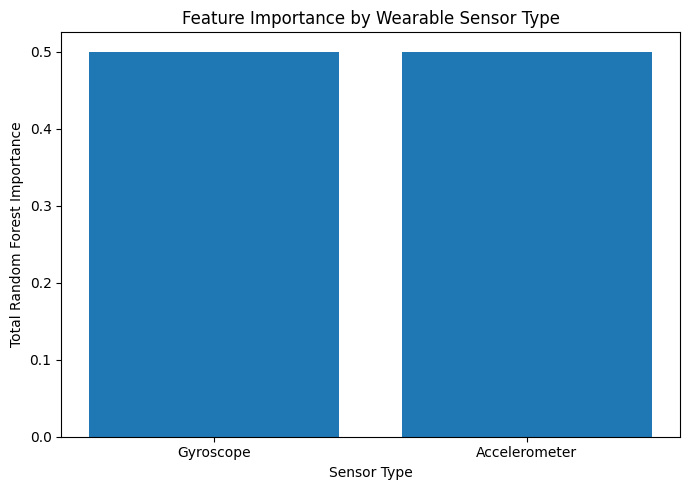

In [57]:
plt.figure(figsize=(7, 5))

plt.bar(
    sensor_importance.index,
    sensor_importance["Total_Importance"]
)

plt.ylabel("Total Random Forest Importance")
plt.xlabel("Sensor Type")
plt.title(
    "Feature Importance by Wearable Sensor Type"
)

plt.tight_layout()
plt.show()

In [59]:
feature_type_importance = (
    importance_categories
    .groupby("Feature_Type")
    .agg(
        Total_Importance=("Mean_Importance", "sum"),
        Mean_Importance=("Mean_Importance", "mean")
    )
    .sort_values(
        "Total_Importance",
        ascending=False
    )
)

display(
    feature_type_importance.round(4)
)

,Total_Importance,Mean_Importance
Feature_Type,,
dominant_frequency,0.1083,0.0135
iqr,0.1024,0.0128
median,0.0919,0.0115
min,0.0888,0.0111
kurtosis,0.0862,0.0108
mean,0.0822,0.0103
skewness,0.0814,0.0102
range,0.0743,0.0093
max,0.0736,0.0092


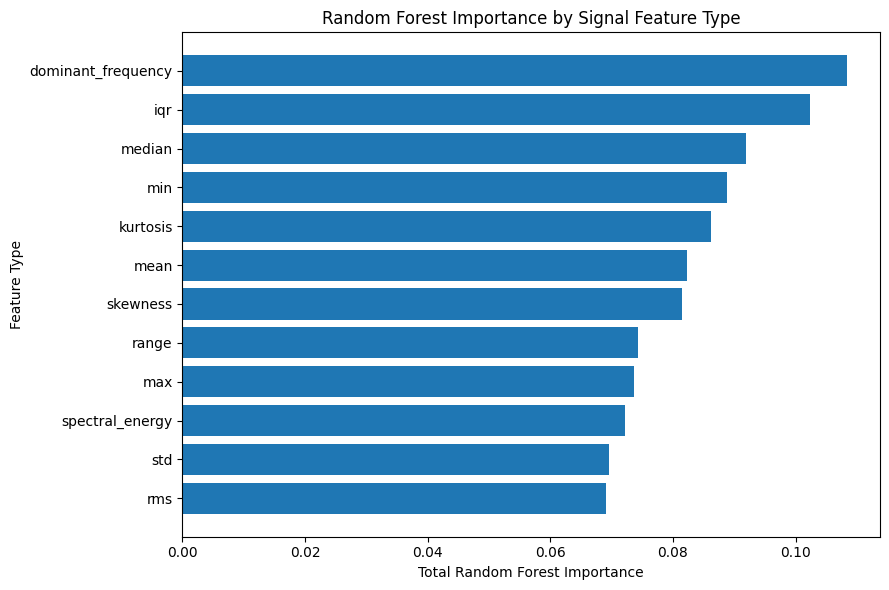

In [61]:
plot_data = (
    feature_type_importance
    .sort_values("Total_Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data.index,
    plot_data["Total_Importance"]
)

plt.xlabel("Total Random Forest Importance")
plt.ylabel("Feature Type")
plt.title(
    "Random Forest Importance by Signal Feature Type"
)

plt.tight_layout()
plt.show()

In [63]:
importance_categories.to_csv(
    OUTPUT_DIR / "rf_feature_importance_categories.csv",
    index=False
)

sensor_importance.to_csv(
    OUTPUT_DIR / "rf_sensor_importance.csv"
)

feature_type_importance.to_csv(
    OUTPUT_DIR / "rf_feature_type_importance.csv"
)

In [65]:
sensor_importance = (
    importance_categories
    .groupby("Sensor")
    .agg(
        Total_Importance=("Mean_Importance", "sum"),
        Mean_Importance=("Mean_Importance", "mean")
    )
    .sort_values(
        "Total_Importance",
        ascending=False
    )
)

display(sensor_importance.round(4))

,Total_Importance,Mean_Importance
Sensor,,
Gyroscope,0.5004,0.0104
Accelerometer,0.4996,0.0104
